In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import nltk


tweets_df = pd.read_csv("https://raw.githubusercontent.com/KCristopher/SentimentAnalysis/main/sts_gold_tweet.csv")
tweets_df.head()

,id,polarity,tweet
0,1467933112,0,the angel is going to miss the athlete this we...
1,2323395086,0,It looks as though Shaq is getting traded to C...
2,1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH
3,1990283756,0,drinking a McDonalds coffee and not understand...
4,1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...


In [21]:
tweets_df.shape

(2034, 3)

In [22]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2034 non-null   int64 
 1   polarity  2034 non-null   int64 
 2   tweet     2034 non-null   object
dtypes: int64(2), object(1)
memory usage: 47.8+ KB


In [23]:
tweets_df['id'].nunique(), len(tweets_df)

(2034, 2034)

In [24]:
tweets_df.groupby('id')['tweet'].nunique().sort_values(ascending = False).head(10)

id
1467812416    1
2052262229    1
2053125094    1
2053014136    1
2052945734    1
2052940465    1
2052939840    1
2052859663    1
2052844839    1
2052807447    1
Name: tweet, dtype: int64

In [25]:
( tweets_df.groupby('id')['tweet'].nunique() == 1 ).all()

True

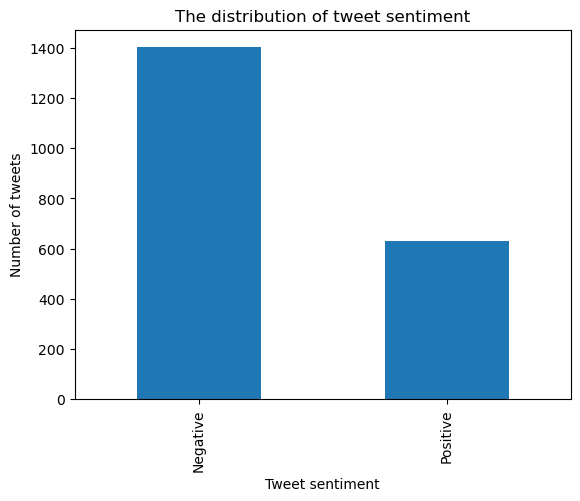

In [26]:
ax = tweets_df['polarity'].value_counts(dropna = False).plot.bar()
plt.title("The distribution of tweet sentiment")
plt.xticks(ax.get_xticks(), ['Negative', 'Positive'])
plt.ylabel('Number of tweets')
plt.xlabel('Tweet sentiment')
plt.show()

In [27]:
sample_tweets = tweets_df[['polarity', 'tweet']].sample(n = 10)

for row in sample_tweets.iterrows() :
    print('\n', row[1]['tweet'], '  >>>>>>>  ', row[1]['polarity'], '\n')


 you guys should check out fred on youtube hes our favorite youtube star    >>>>>>>   4 


 right about now i wish the psp had 2 shoulder buttons    >>>>>>>   0 


 @JonathanRKnight i'd share my latte with you. just got back from a starbucks run myself    >>>>>>>   4 


 Wow, another sunny day in London! Maybe it really has changed its mind about being a miserable sod all the time    >>>>>>>   4 


 And the west was won! Yeah lakers!    >>>>>>>   4 


 LAKERS FTW BABYY!! my boys did work tonight!!!    >>>>>>>   4 


 About to head to Sydney. Drinks, friends, ink, Amity Affliction, Getaway Plan and Elora Danan! Fun times await!     >>>>>>>   4 


 @nick_carter Aww Nick!! I like your hair longer, why did you cut it off?  Break. My. Heart.   >>>>>>>   0 


 my dog has cancer.    >>>>>>>   0 


 just got home from watching Michigan State get tromped!      >>>>>>>   0 



In [28]:
tweets_df['tweet_length'] = tweets_df['tweet'].str.len()
tweets_df['tweet_length'].describe().round(2)

count    2034.00
mean       80.81
std        35.36
min        11.00
25%        51.00
50%        77.50
75%       111.00
max       148.00
Name: tweet_length, dtype: float64

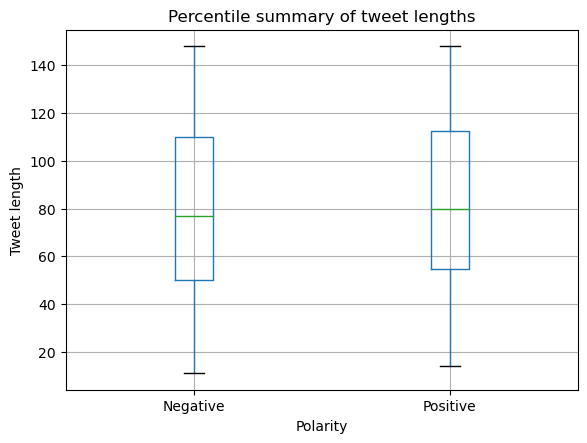

In [29]:
lengths_box = tweets_df.boxplot(column='tweet_length', by='polarity')
plt.suptitle('')
plt.title('Percentile summary of tweet lengths')
plt.xticks( lengths_box.get_xticks(), [ 'Negative', 'Positive' ] )
plt.ylabel('Tweet length')
plt.xlabel('Polarity')

plt.show()

In [31]:
tweets_df.set_index('id', inplace = True)
tweets_df.head()

,polarity,tweet,tweet_length
id,,,
1467933112,0,the angel is going to miss the athlete this we...,52
2323395086,0,It looks as though Shaq is getting traded to C...,126
1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH,46
1990283756,0,drinking a McDonalds coffee and not understand...,100
1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...,51


In [33]:
y = tweets_df['polarity']
X = tweets_df.drop('polarity', axis = 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

trainset = pd.concat( [ X_train, y_train ], axis = 1  )
testset = pd.concat( [ X_test, y_test ], axis = 1  )

In [34]:
trainset.shape, testset.shape

((1362, 3), (672, 3))

In [35]:
trainset.polarity.value_counts(normalize = True).round(2)

0    0.7
4    0.3
Name: polarity, dtype: float64

In [36]:
testset.polarity.value_counts(normalize = True).round(2)

0    0.68
4    0.32
Name: polarity, dtype: float64

In [47]:
words_dataset = ' '.join( trainset['tweet'].tolist() )
words_dataset[ : 100]

'Facebook Make me SAD  T.T Anyone using #TweetDeck?  Their latest version update v0.25.1b still does '

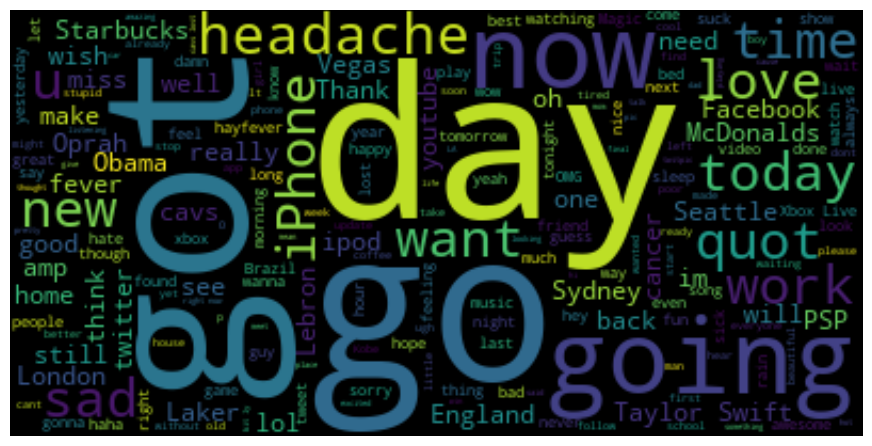

In [48]:
# Create and generate a word cloud image:
wordcloud = WordCloud().generate(words_dataset)

# Display the generated image:
plt.figure(figsize=(11,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [49]:
trainset.head(3)

,tweet,tweet_length,polarity
id,,,
2175019150,Facebook Make me SAD T.T,25,0
2174569897,Anyone using #TweetDeck? Their latest version...,119,0
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,91,4


In [52]:
raw_tokens_dataset = [ t for tweet in trainset.tweet for t in tweet.split() ]
raw_tokens_dataset[ : 10]

['Facebook',
 'Make',
 'me',
 'SAD',
 'T.T',
 'Anyone',
 'using',
 '#TweetDeck?',
 'Their',
 'latest']

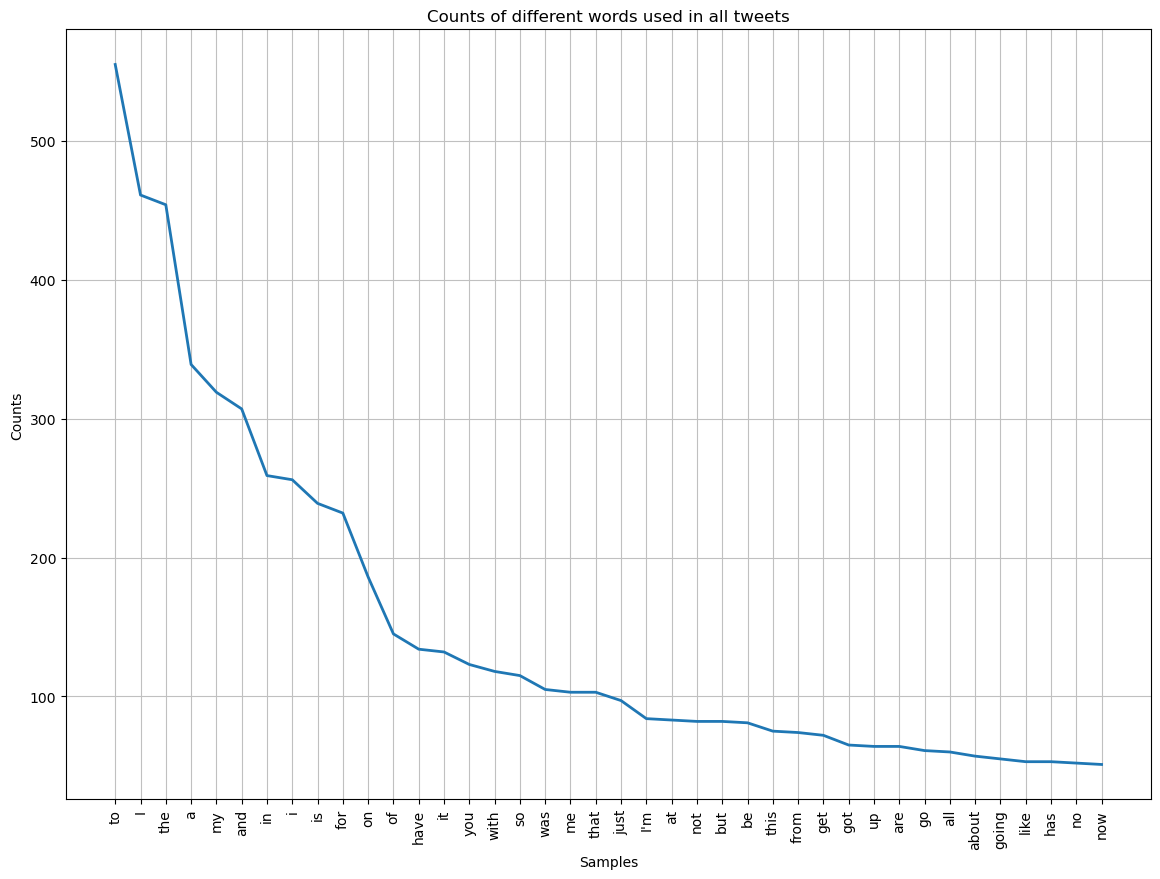

In [53]:
# Creating the word frequency distribution
freqdist = nltk.FreqDist(raw_tokens_dataset)

# Plotting the word frequency distribution
plt.figure(figsize=(14,10))
freqdist.plot(40,title='Counts of different words used in all tweets')

plt.show()